Loaded 10324 triples
Rows after restricting to ['increased', 'decreased', 'no_significant_change']: 6912
'solubility': 10 sources shown (of 30 clearing the threshold)
'water holding capacity': 10 sources shown (of 21 clearing the threshold)
'foaming capacity': 10 sources shown (of 15 clearing the threshold)
'foam stability': 6 sources shown (of 6 clearing the threshold)
'oil holding capacity': 8 sources shown (of 8 clearing the threshold)
'emulsifying activity index': 7 sources shown (of 7 clearing the threshold)


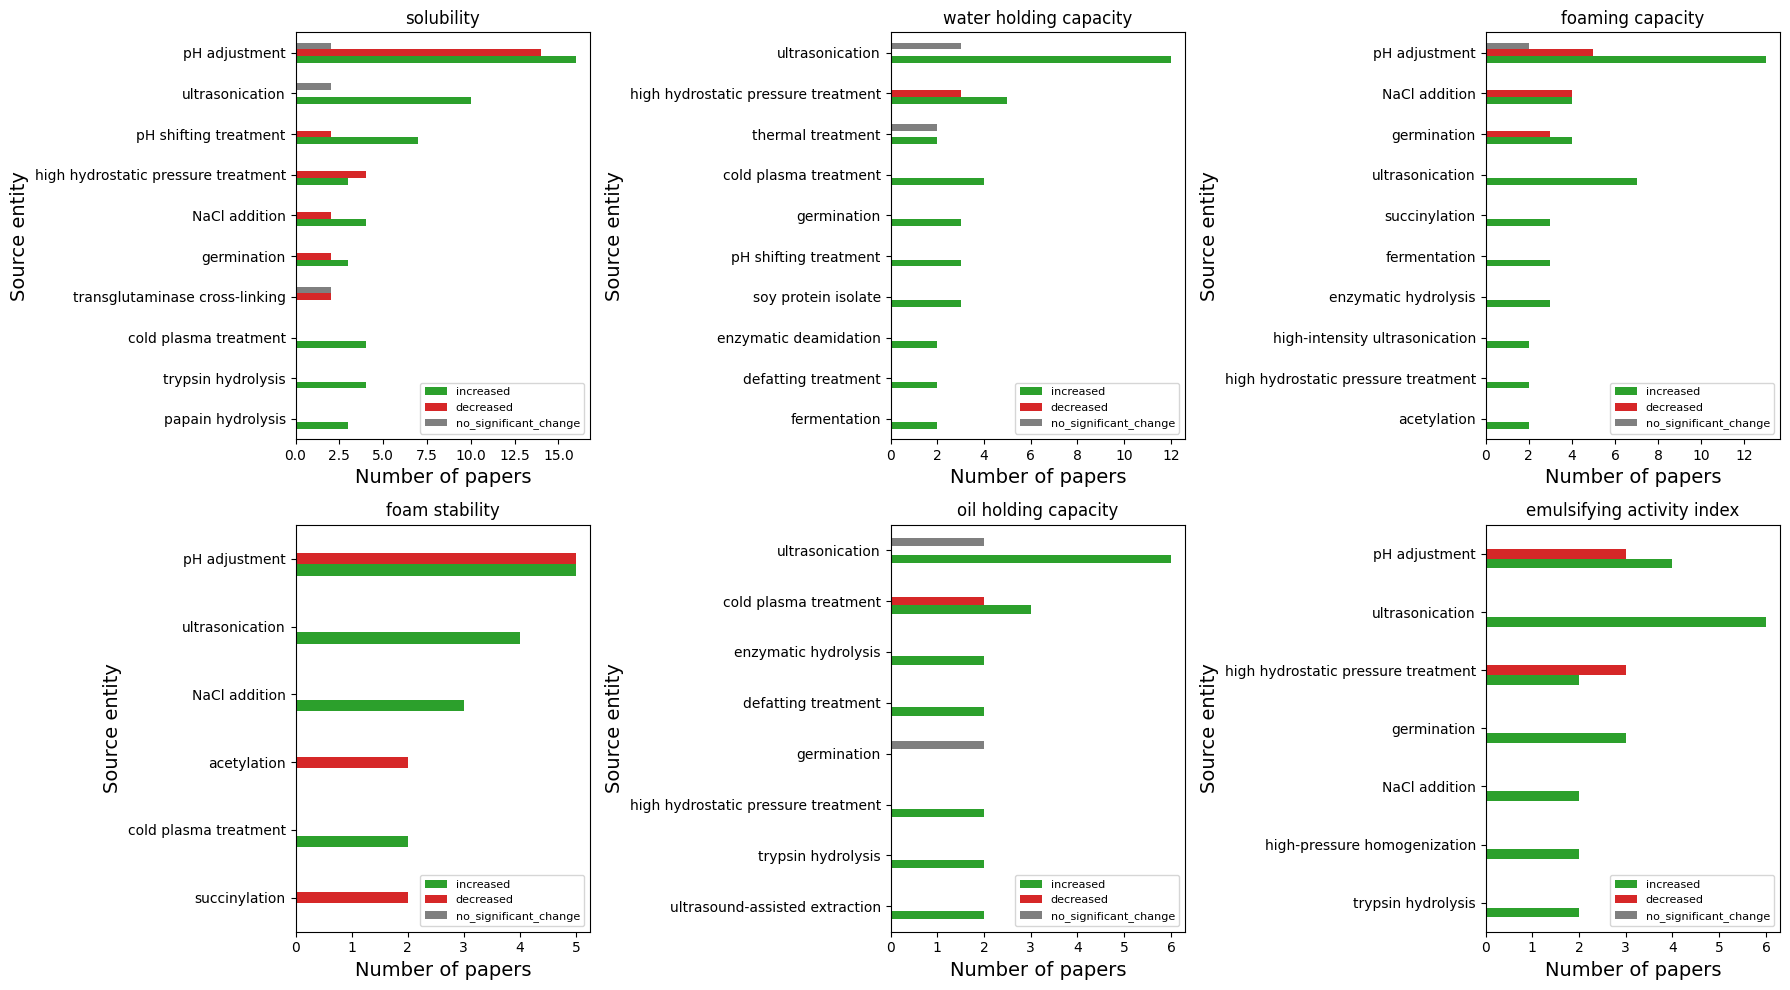


Saved chart to target_source_interaction_charts.png
Saved underlying frequency tables to target_source_interaction_frequencies.xlsx


In [8]:
"""
For each of your top target entities (by doi-adjusted frequency),
show the top 10 source entities linked to it via increased/decreased/
no_significant_change interactions, doi-adjusted, with a minimum
doc_frequency of 2 per (source, target, interaction) combination to
suppress singleton noise, important given this corpus is still small
enough that most source-target pairs are one-paper mentions.

One grouped-bar panel per target entity: x-axis = top 10 sources,
grouped bars = the 3 interaction types, so you can see at a glance
whether a given source increases, decreases, or has no significant
effect on that target, and how many papers support each.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "final_formatting_cleaned_triples - Copy.xlsx"
SOURCE_COL = "resolved_source"
TARGET_COL = "resolved_target"
INTERACTION_COL = "interaction"
DOI_COL = "doi"

# Top target entities, from your frequency chart. "foam stability" used
# (not "foaming stability", a separate, lower-ranked entity, matched by
# rank position from your chart, correct me if you meant the other one).
TARGET_ENTITIES = [
    "solubility", "water holding capacity", "foaming capacity",
    "foam stability", "oil holding capacity", "emulsifying activity index",
]

INTERACTIONS_TO_INCLUDE = ["increased", "decreased", "no_significant_change"]
MIN_SOURCE_DOC_FREQ = 2  # drop singleton sources, dataset still small
TOP_N_SOURCES = 10

OUTPUT_PLOT = "target_source_interaction_charts.png"
OUTPUT_XLSX = "target_source_interaction_frequencies.xlsx"

# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
df = pd.read_excel(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

df = df[df[INTERACTION_COL].isin(INTERACTIONS_TO_INCLUDE)]
print(f"Rows after restricting to {INTERACTIONS_TO_INCLUDE}: {len(df)}")

# ---------------------------------------------------------------
# BUILD PER-TARGET, PER-SOURCE, PER-INTERACTION DOC FREQUENCY
# ---------------------------------------------------------------
pivot_tables = {}
full_freq_tables = {}

for target in TARGET_ENTITIES:
    subset = df[df[TARGET_COL] == target]
    if subset.empty:
        print(f"WARNING: no rows found for target {target!r}, check exact spelling/casing")
        pivot_tables[target] = pd.DataFrame()
        continue

    # doc frequency per (source, interaction) combination, RAW, before
    # any threshold filtering, this is what lets you distinguish "never
    # reported" (no row at all here) from "reported but filtered out"
    # (a row here with raw_doc_frequency below MIN_SOURCE_DOC_FREQ)
    raw_doc_freq = (
        subset.groupby([SOURCE_COL, INTERACTION_COL])[DOI_COL]
        .nunique()
        .reset_index()
        .rename(columns={DOI_COL: "raw_doc_frequency"})
    )
    raw_doc_freq["meets_min_threshold"] = raw_doc_freq["raw_doc_frequency"] >= MIN_SOURCE_DOC_FREQ
    full_freq_tables[target] = raw_doc_freq.sort_values("raw_doc_frequency", ascending=False)

    # doc frequency per (source, interaction) combination
    doc_freq = raw_doc_freq.rename(columns={"raw_doc_frequency": "doc_frequency"})
    doc_freq = doc_freq[doc_freq["doc_frequency"] >= MIN_SOURCE_DOC_FREQ]

    if doc_freq.empty:
        print(f"'{target}': no sources cleared doc_frequency >= {MIN_SOURCE_DOC_FREQ}")
        pivot_tables[target] = pd.DataFrame()
        continue

    # rank sources by their TOTAL doc frequency across the 3 interactions
    top_sources = (
        doc_freq.groupby(SOURCE_COL)["doc_frequency"].sum()
        .sort_values(ascending=False)
        .head(TOP_N_SOURCES)
        .index
    )
    pivot = doc_freq[doc_freq[SOURCE_COL].isin(top_sources)].pivot(
        index=SOURCE_COL, columns=INTERACTION_COL, values="doc_frequency"
    ).reindex(top_sources).fillna(0)
    for interaction in INTERACTIONS_TO_INCLUDE:
        if interaction not in pivot.columns:
            pivot[interaction] = 0
    pivot_tables[target] = pivot[INTERACTIONS_TO_INCLUDE]

    print(f"'{target}': {len(top_sources)} sources shown (of {doc_freq[SOURCE_COL].nunique()} clearing the threshold)")

# ---------------------------------------------------------------
# PLOT: ONE GROUPED-BAR PANEL PER TARGET
# ---------------------------------------------------------------
n_targets = len(TARGET_ENTITIES)
n_cols = 3
n_rows = int(np.ceil(n_targets / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).reshape(-1)

colors = {"increased": "tab:green", "decreased": "tab:red", "no_significant_change": "tab:gray"}

for ax, target in zip(axes, TARGET_ENTITIES):
    pivot = pivot_tables.get(target, pd.DataFrame())
    if pivot.empty:
        ax.text(0.5, 0.5, f"No sources with\ndoc_frequency >= {MIN_SOURCE_DOC_FREQ}", ha="center", va="center")
        ax.set_title(target)
        ax.axis("off")
        continue
    pivot.iloc[::-1].plot(kind="barh", stacked=False, ax=ax,
                           color=[colors[c] for c in pivot.columns])
    ax.set_title(target)
    ax.set_xlabel("Number of papers", fontsize=14)
    ax.set_ylabel("Source entity", fontsize=14)
    ax.legend(fontsize=8)

for ax in axes[n_targets:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=600, bbox_inches="tight")
plt.show()
print(f"\nSaved chart to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE UNDERLYING TABLES
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    for target in TARGET_ENTITIES:
        table = full_freq_tables.get(target, pd.DataFrame())
        sheet_name = target[:31].replace("/", "-")  # Excel sheet name limits
        table.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Saved underlying frequency tables to {OUTPUT_XLSX}")